In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -U ultralytics roboflow

In [5]:
import torch
print("GPU Available:", torch.cuda.is_available())
!nvidia-smi

GPU Available: True
Sun Aug  9 20:14:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             15W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [6]:
from roboflow import Roboflow
rf = Roboflow(api_key="6PiC3j6Kkj67AYQklopn")
project = rf.workspace("muqqadas-iftikhar").project("safety-helmet-detection-e4zru")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Safety-Helmet-Detection-1 in yolov8:: 100%|██████████| 426/426 [00:00<00:00, 7999.99it/s]

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/Safety-Helmet-Detection-1/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    pretrained=True,
    project="/content/drive/MyDrive/Safety_Helmet_Detection/training_results",
    name="yolov8n_baseline"
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Safety-Helmet-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_baseline, 

In [9]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Safety_Helmet_Detection/training_results/yolov8n_baseline/weights/best.pt")

results = model.predict(
    source="/content/Safety-Helmet-Detection-1/test/images",
    conf=0.35,
    save=True,
    project="/content/drive/MyDrive/Safety_Helmet_Detection/predictions",
    name="test_predictions"
)

print(f"Total test images processed: {len(results)}")


image 1/18 /content/Safety-Helmet-Detection-1/test/images/-108_png_jpg.rf.3042a54a960c7c40bc854f8303f36b36.jpg: 640x640 1 Person, 1 helmet, 7.2ms
image 2/18 /content/Safety-Helmet-Detection-1/test/images/-114_png_jpg.rf.30914c1623238c290f03182774834aa7.jpg: 640x640 1 Person, 1 helmet, 7.2ms
image 3/18 /content/Safety-Helmet-Detection-1/test/images/-141_png_jpg.rf.89174ed91a11e340a5e3cd2163146405.jpg: 640x640 1 Person, 1 helmet, 1 without_helmet, 7.2ms
image 4/18 /content/Safety-Helmet-Detection-1/test/images/-149_png_jpg.rf.8b1760a51768226d1fce17d228faccee.jpg: 640x640 1 Person, 1 helmet, 7.2ms
image 5/18 /content/Safety-Helmet-Detection-1/test/images/-18_png_jpg.rf.1b9446d3dc6da041b87ae72c52d58b03.jpg: 640x640 1 Person, 1 helmet, 7.2ms
image 6/18 /content/Safety-Helmet-Detection-1/test/images/-25_png_jpg.rf.86fc2bc4ff700d03d2d00941037f0dfd.jpg: 640x640 1 helmet, 9.7ms
image 7/18 /content/Safety-Helmet-Detection-1/test/images/-39_png_jpg.rf.9df694eac73977907381a76d36463932.jpg: 640x64

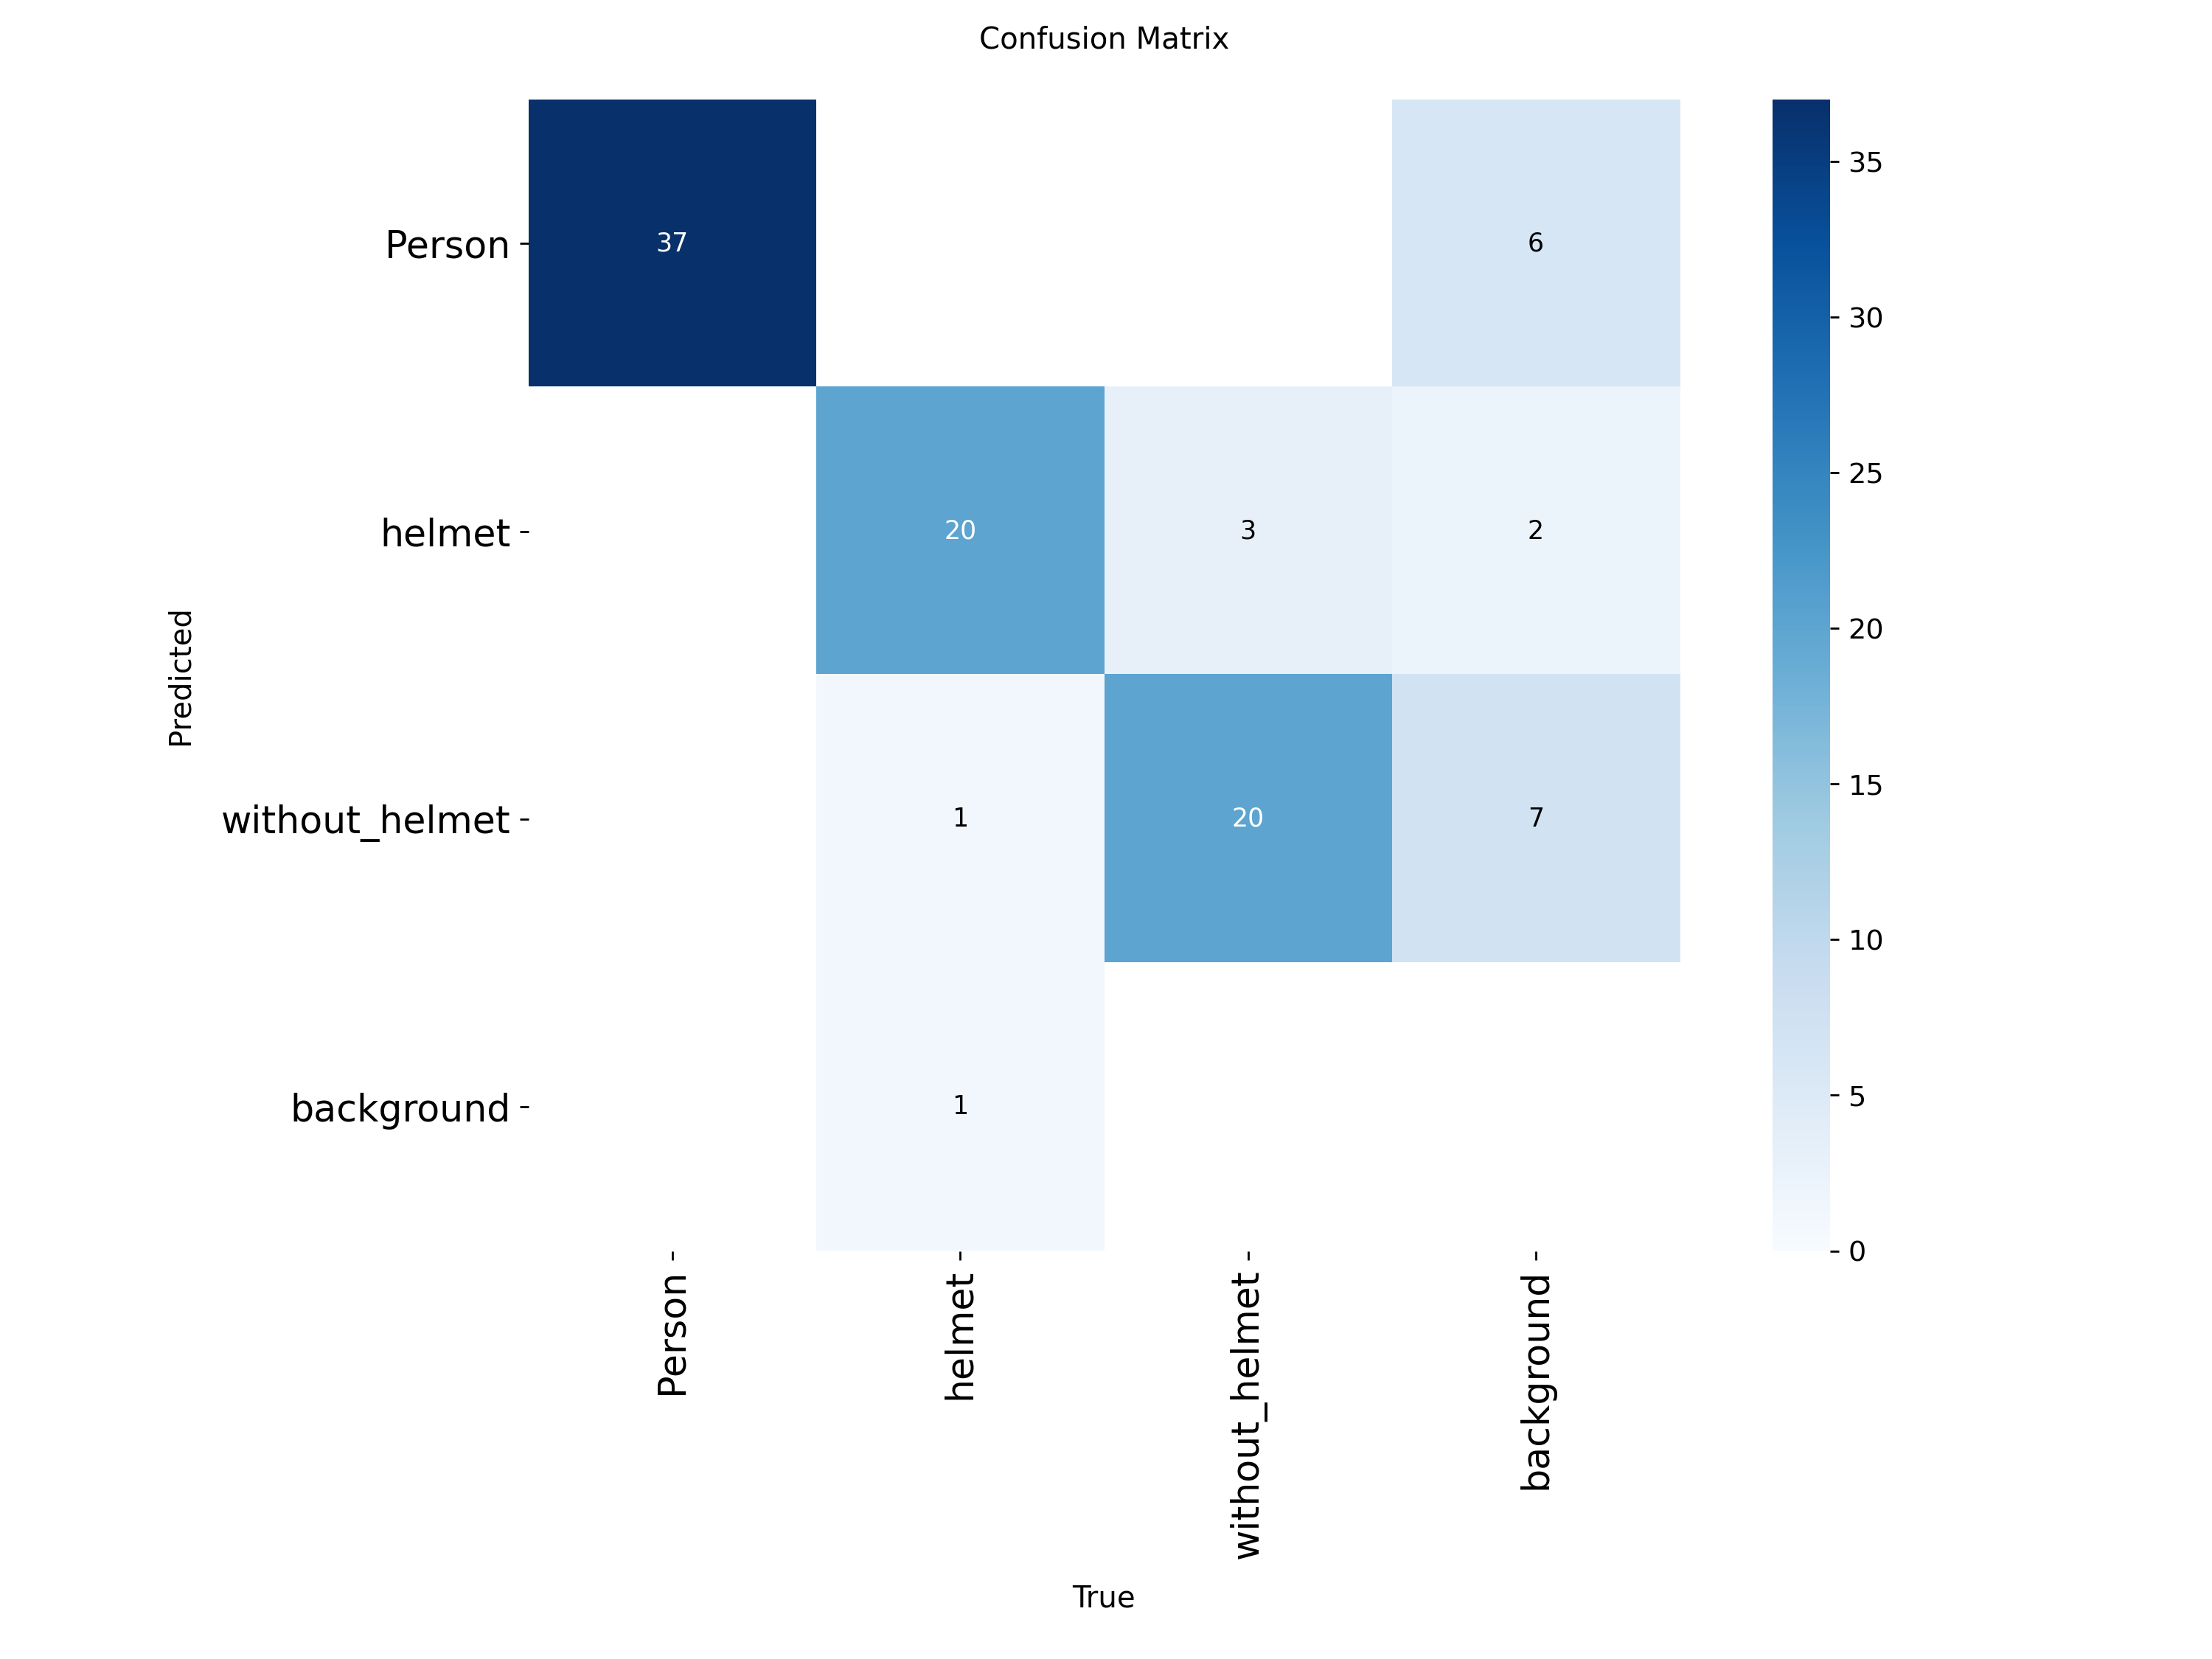

In [10]:
from IPython.display import Image, display
display(Image(filename="/content/drive/MyDrive/Safety_Helmet_Detection/training_results/yolov8n_baseline/confusion_matrix.png"))

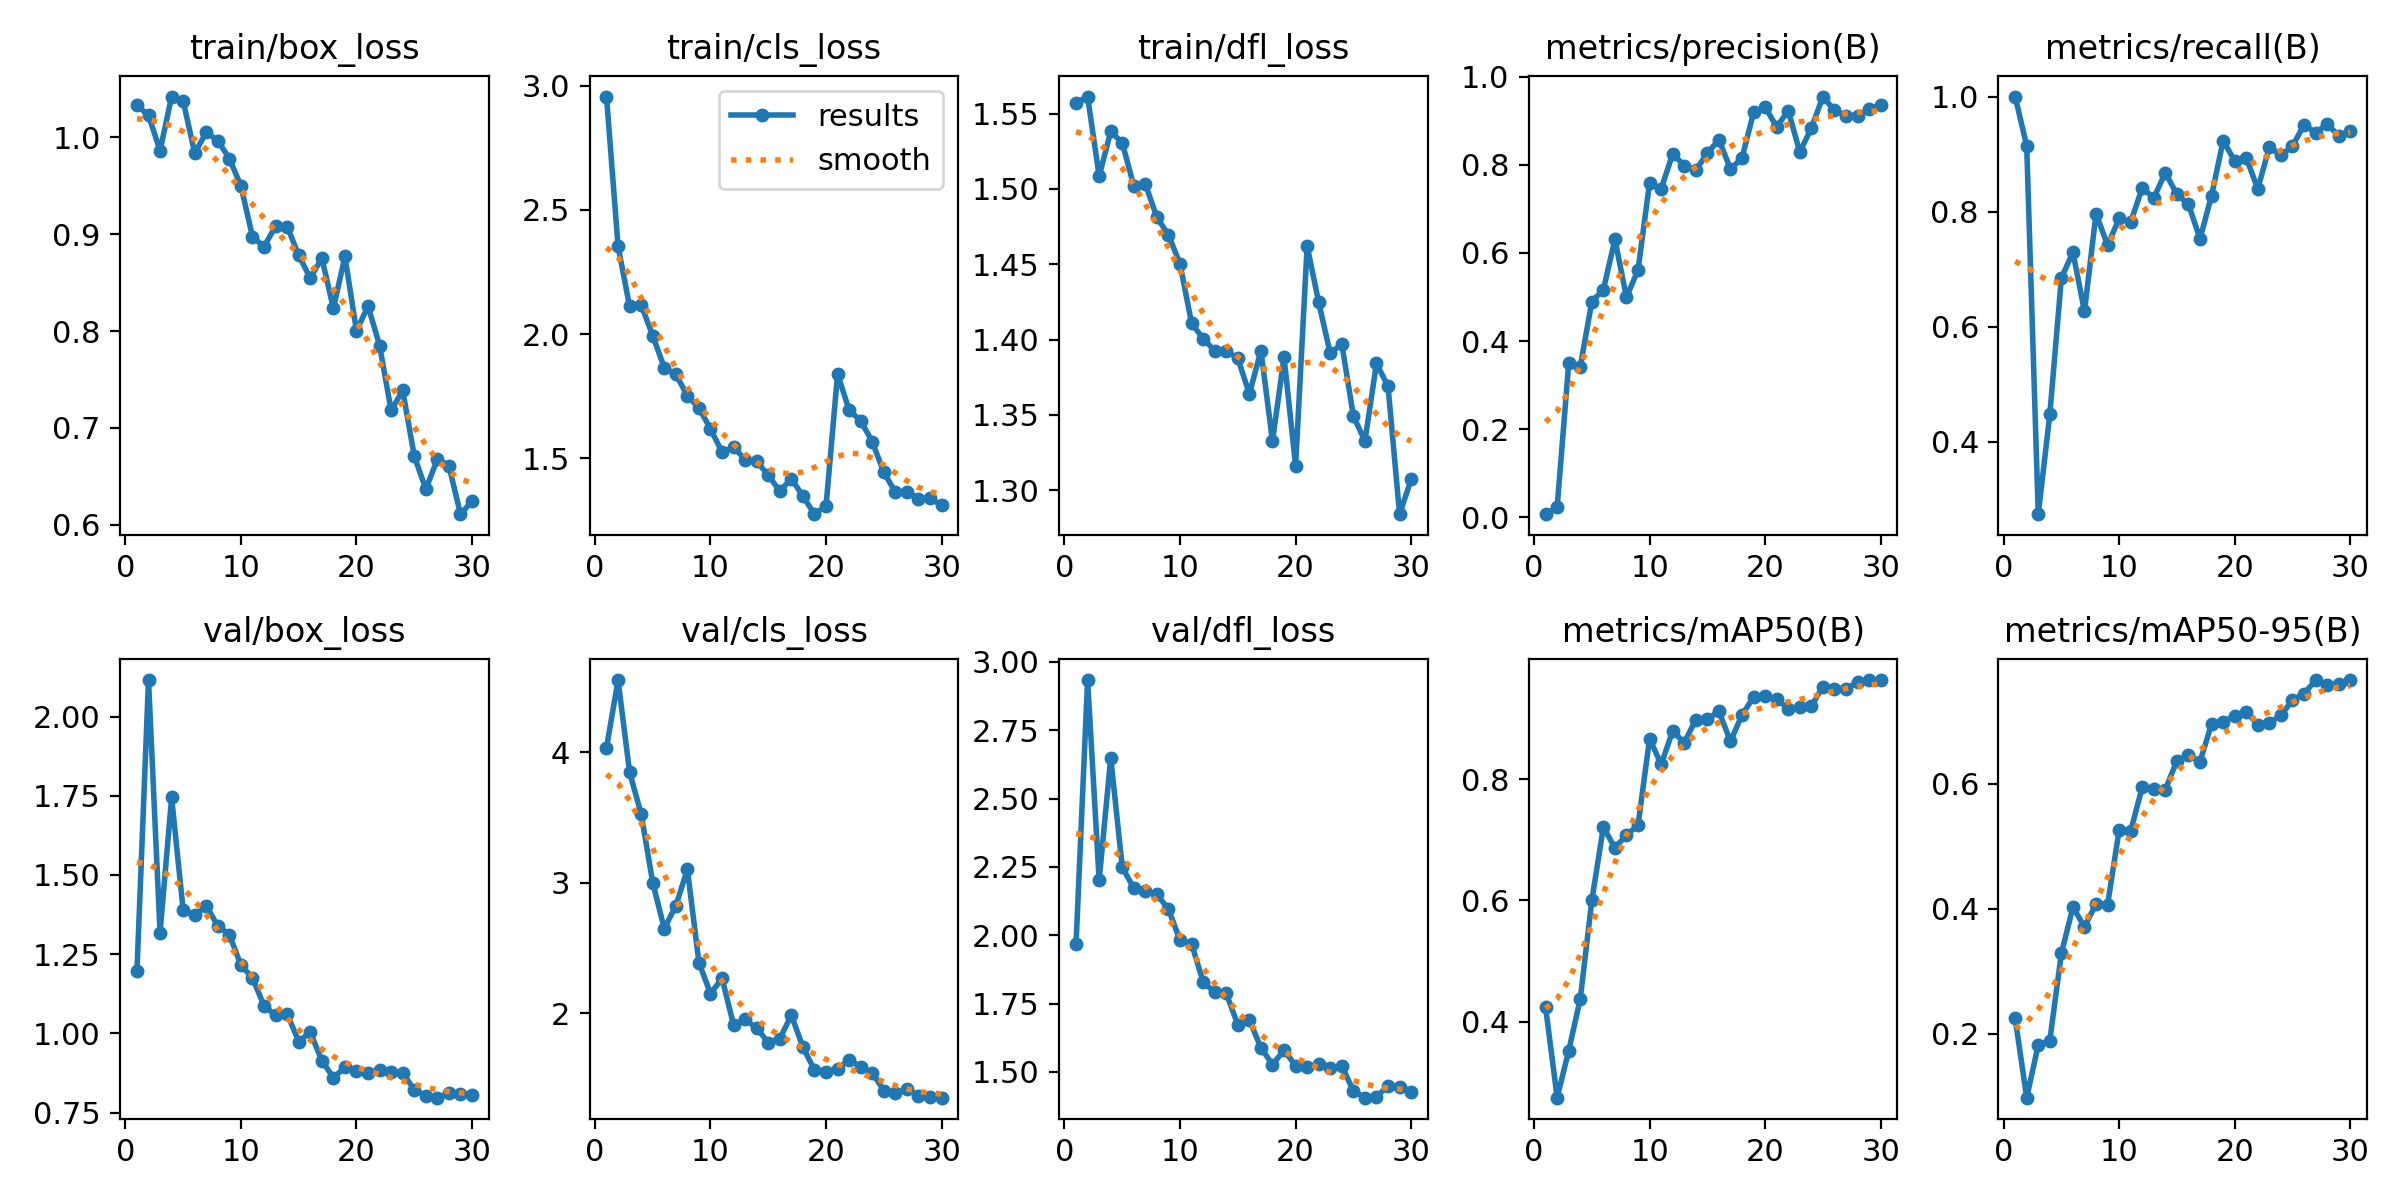

In [11]:
display(Image(filename="/content/drive/MyDrive/Safety_Helmet_Detection/training_results/yolov8n_baseline/results.png"))

Total prediction images: 18


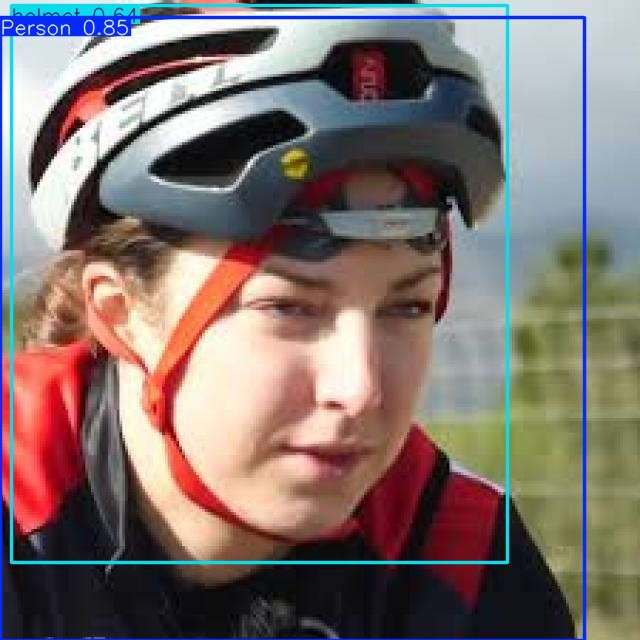

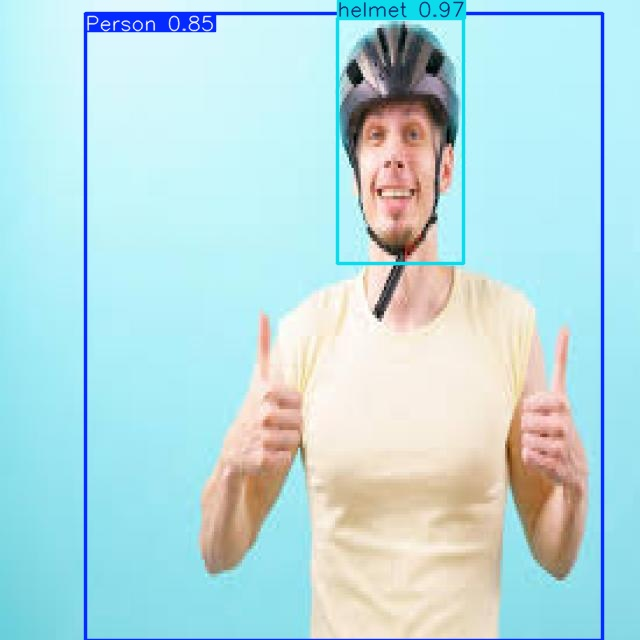

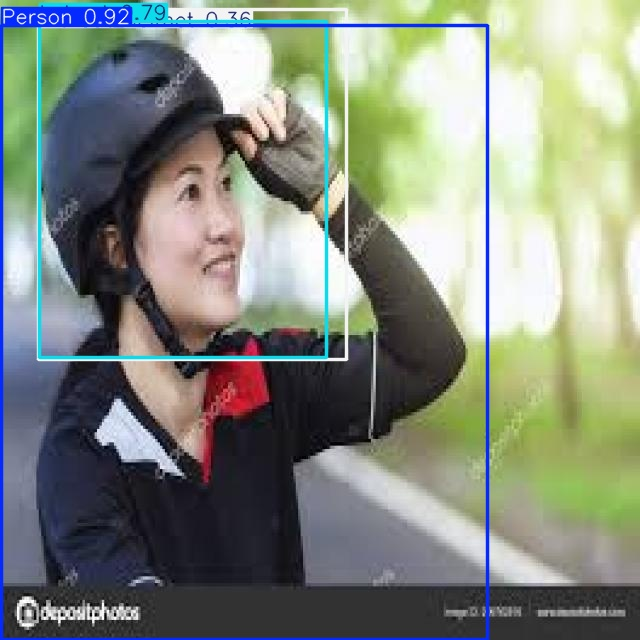

In [12]:
import glob
from IPython.display import Image, display

pred_images = glob.glob("/content/drive/MyDrive/Safety_Helmet_Detection/predictions/test_predictions/*.jpg")
print(f"Total prediction images: {len(pred_images)}")

# Pehli 3 dikhate hain sample ke tor pe
for img_path in pred_images[:3]:
    display(Image(filename=img_path))

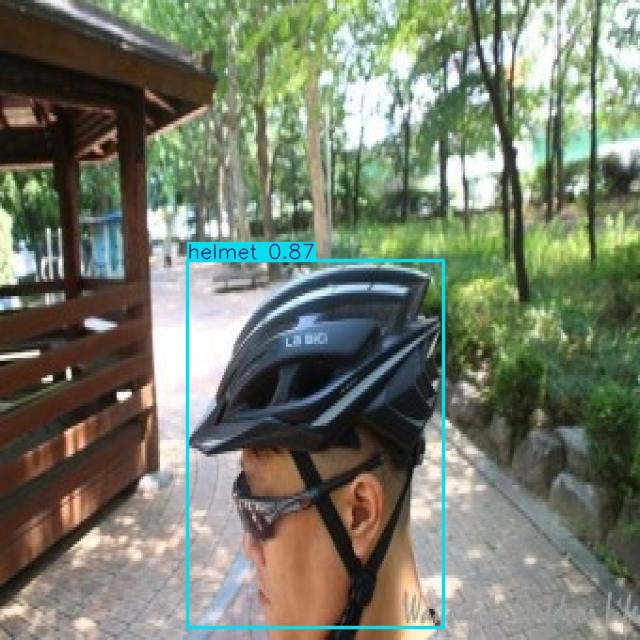

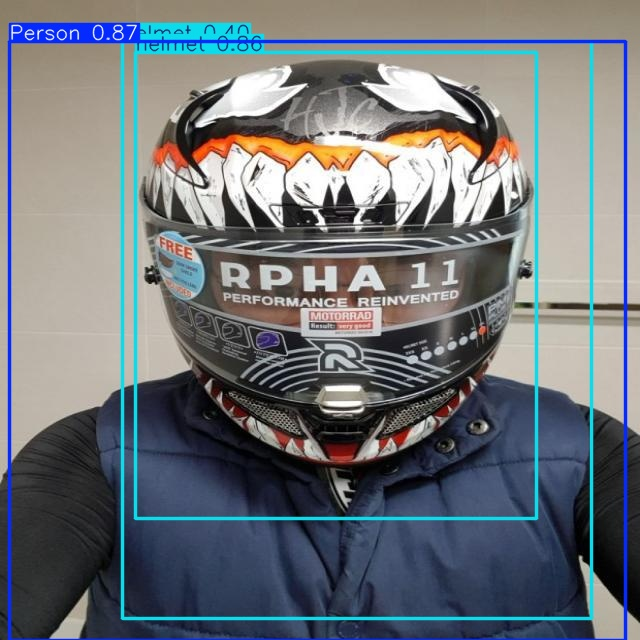

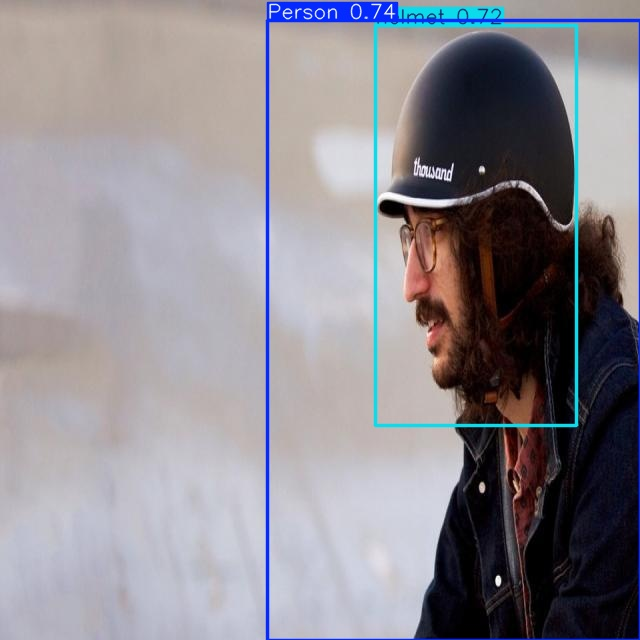

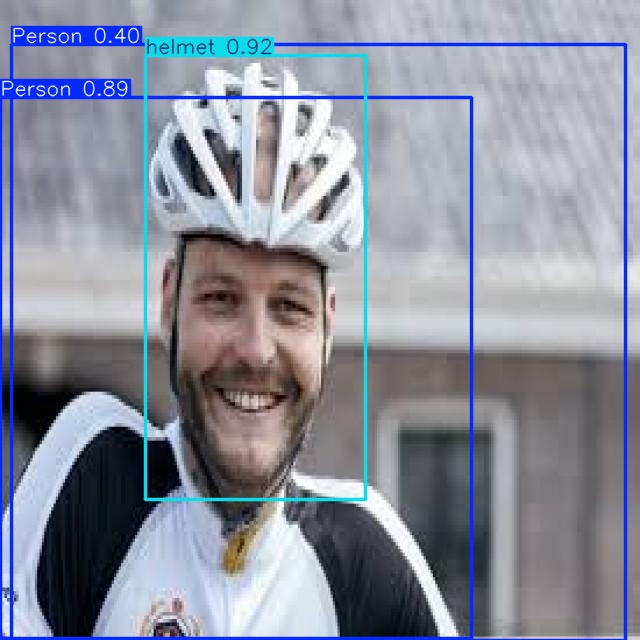

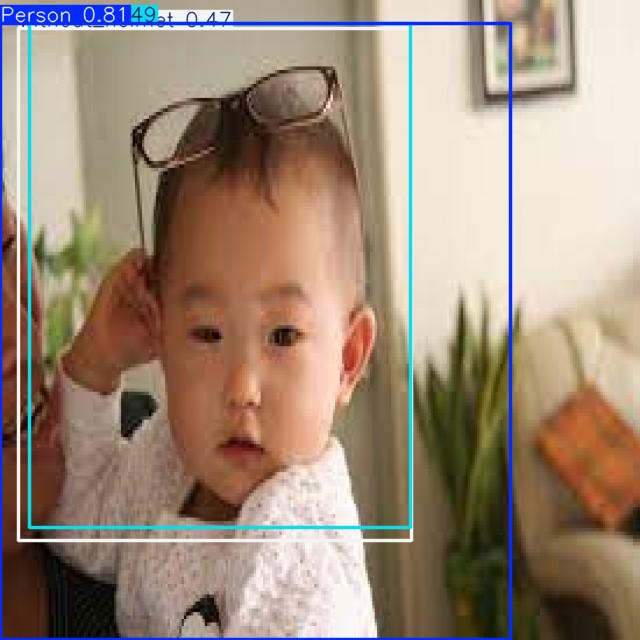

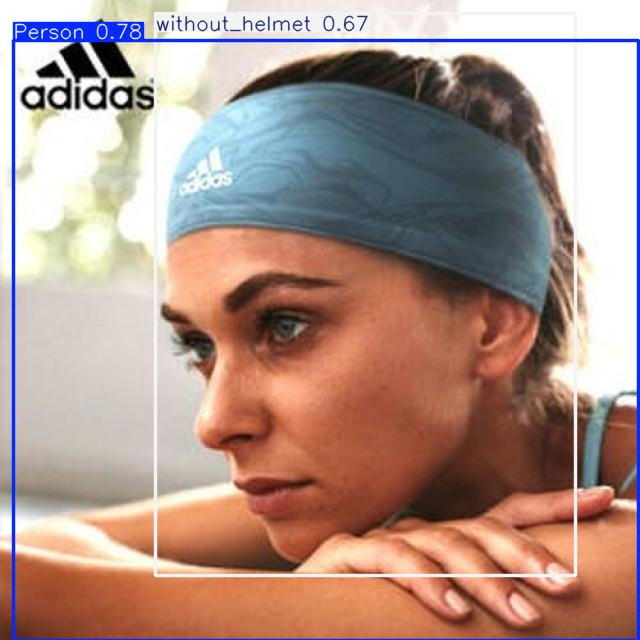

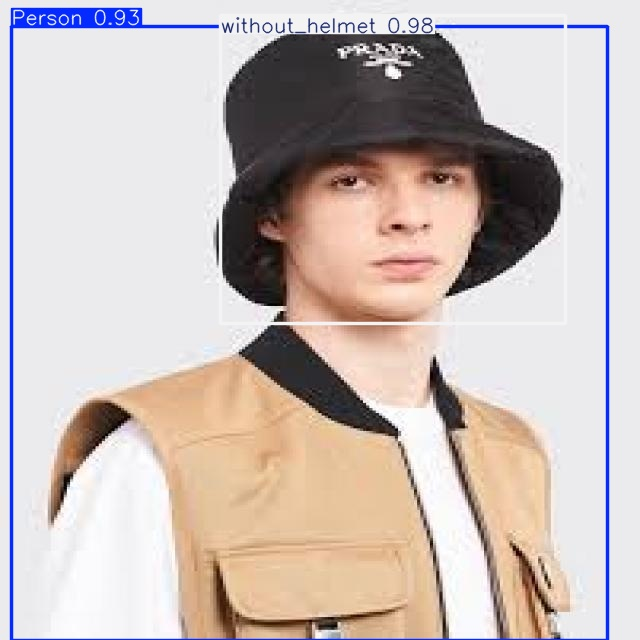

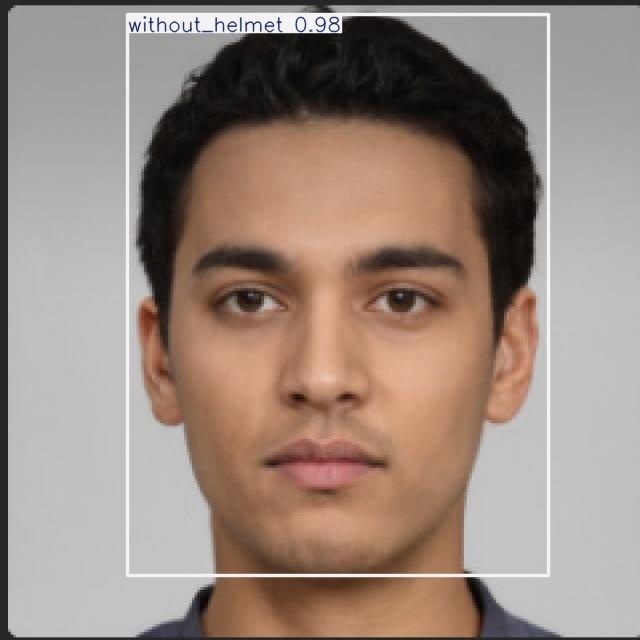

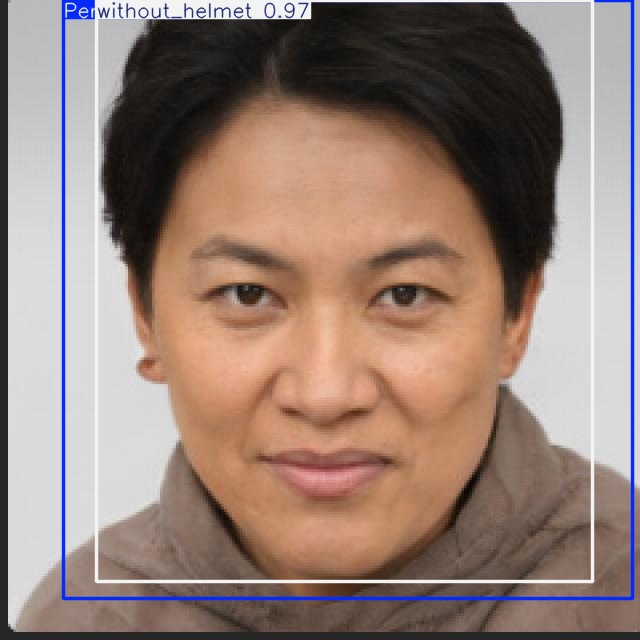

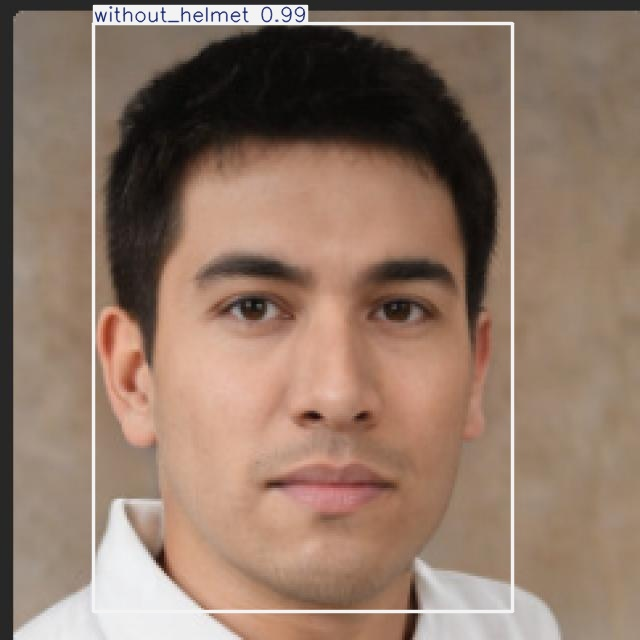

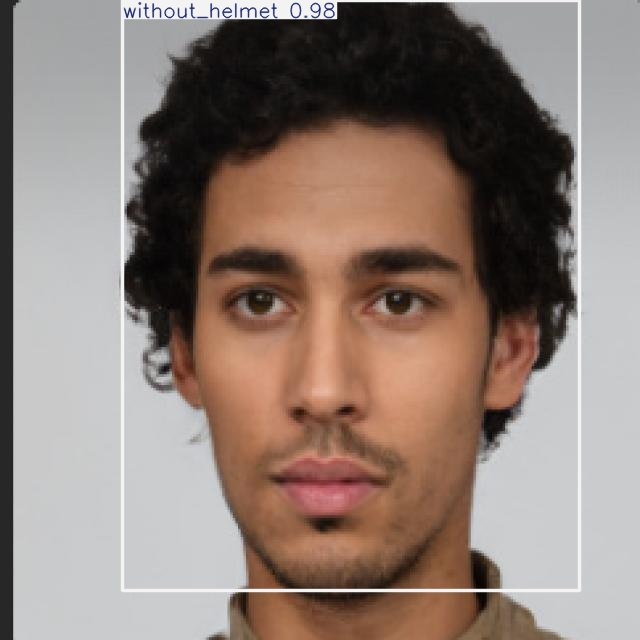

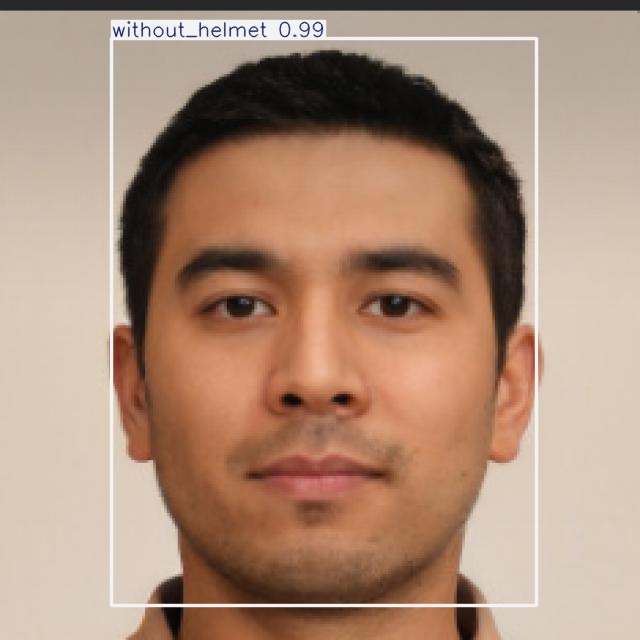

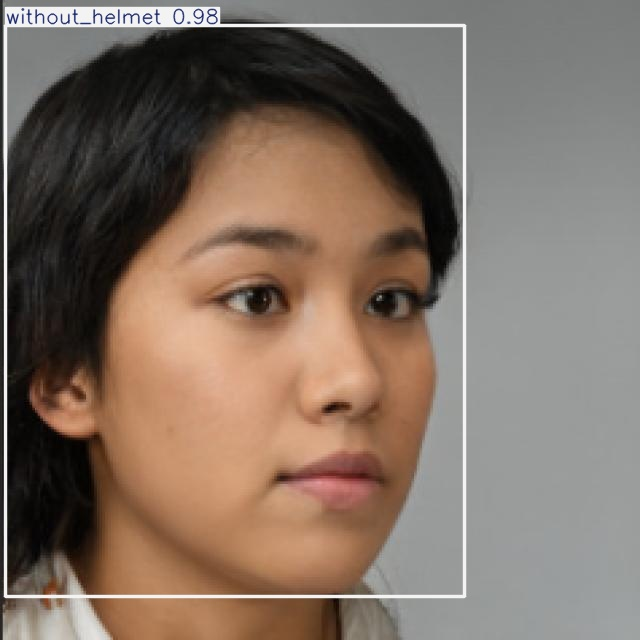

In [13]:
for img_path in pred_images[5:18]:
    display(Image(filename=img_path))

In [14]:
import os
os.makedirs("/content/drive/MyDrive/Safety_Helmet_Detection/report", exist_ok=True)
print("Done")

Done
